# 16 Индексирање и транспоновање табеле

За лакши рад са врстама пожељно је да имамо колону у којој су вредности једнозначно одређене и по којима можемо да препознамо врсте. Када одредимо колону која нам највише одговара ми је прогласимо за кључ, односно, индексирамо је. За табелу из претходне лекције то изгледа овако:

In [1]:
import pandas as pd
ученици=[["Алекса Алексић",       "1а",4.82,34,2],
         ["Бранко Бранковић",     "2д",4.33,98,1],
         ["Владимир Владимировић","3ц",5.00,55,0],
         ["Гаврило Гавриловић",   "2б",4.56,11,0],
         ["Дејана Дејанић",       "1е",4.86,21,0],
         ["Ђурђа Ђурђевић",       "4а",4.92,44,6],
         ["Ерик Ериксон",         "3б",5.00,32,8],
         ["Жика Жикић",           "4д",4.77,36,1],
         ["Здравко Здравковић",   "1д",4.88,35,0],
         ["Иван Ивановић",        "3е",4.88,67,0],
         ["Јована Јовановић",     "2ц",4.82,88,1],
         ["Коста Костић",         "1б",4.50,37,2]]
табела=pd.DataFrame(ученици)
табела.columns=["име и презиме", "одељење", "просек", "оправдани", "неоправдани"]
нова_табела=табела.set_index("име и презиме")

Почетна табела и нова табела се разликују и изгледају овако:

In [2]:
табела

,име и презиме,одељење,просек,оправдани,неоправдани
0,Алекса Алексић,1а,4.82,34,2
1,Бранко Бранковић,2д,4.33,98,1
2,Владимир Владимировић,3ц,5.00,55,0
3,Гаврило Гавриловић,2б,4.56,11,0
4,Дејана Дејанић,1е,4.86,21,0
5,Ђурђа Ђурђевић,4а,4.92,44,6
6,Ерик Ериксон,3б,5.00,32,8
7,Жика Жикић,4д,4.77,36,1
8,Здравко Здравковић,1д,4.88,35,0
9,Иван Ивановић,3е,4.88,67,0


In [3]:
нова_табела

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Алекса Алексић,1а,4.82,34,2
Бранко Бранковић,2д,4.33,98,1
Владимир Владимировић,3ц,5.00,55,0
Гаврило Гавриловић,2б,4.56,11,0
Дејана Дејанић,1е,4.86,21,0
Ђурђа Ђурђевић,4а,4.92,44,6
Ерик Ериксон,3б,5.00,32,8
Жика Жикић,4д,4.77,36,1
Здравко Здравковић,1д,4.88,35,0


Првој колони нове табеле не можемо да приступимо као до сада, већ на следећи начин:

In [4]:
нова_табела.index

Index(['Алекса Алексић', 'Бранко Бранковић', 'Владимир Владимировић',
       'Гаврило Гавриловић', 'Дејана Дејанић', 'Ђурђа Ђурђевић',
       'Ерик Ериксон', 'Жика Жикић', 'Здравко Здравковић', 'Иван Ивановић',
       'Јована Јовановић', 'Коста Костић'],
      dtype='object', name='име и презиме')

Индексирану табелу графички приказујемо на следећи начин:

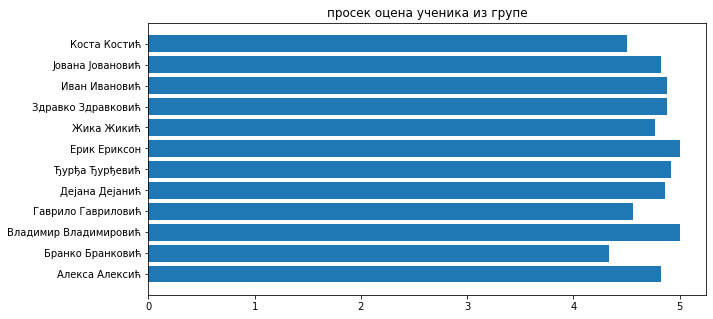

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.barh(нова_табела.index, нова_табела["просек"])
plt.title("просек оцена ученика из групе")
plt.show()
plt.close()

### 16.1 Приступ врстама и појединачним ћелијама индексиране табеле

Табеле из структуре DataFrame су оптимизоване за рад са колонама. У ситуацијама када желимо да нешто радимо са врстама користимо функцију loc што је скраћено од енглеске речи location.

In [8]:
нова_табела.loc["Иван Ивановић"]

одељење          3е
просек         4.88
оправдани        67
неоправдани       0
Name: Иван Ивановић, dtype: object

Функцију loc можемо да користимо за лоцирање неколико спојених врста или за лоцирање једног елемента као и за издвајање више параметара.

In [9]:
нова_табела.loc["Гаврило Гавриловић":"Иван Ивановић"]

,одељење,просек,оправдани,неоправдани
име и презиме,,,,
Гаврило Гавриловић,2б,4.56,11,0
Дејана Дејанић,1е,4.86,21,0
Ђурђа Ђурђевић,4а,4.92,44,6
Ерик Ериксон,3б,5.00,32,8
Жика Жикић,4д,4.77,36,1
Здравко Здравковић,1д,4.88,35,0
Иван Ивановић,3е,4.88,67,0


In [10]:
нова_табела.loc["Иван Ивановић","оправдани"]

67

In [11]:
нова_табела.loc["Ерик Ериксон":"Иван Ивановић","оправдани":"неоправдани"]

,оправдани,неоправдани
име и презиме,,
Ерик Ериксон,32,8
Жика Жикић,36,1
Здравко Здравковић,35,0
Иван Ивановић,67,0


### 16.2 Рачун по врстама и колонама табеле

За рачунање по врстама и колонама табеле користићемо табелу са разредима једне школе и њиховим просечним оценама по тромесечијима.

In [12]:
школа=[["I",4.56,4.35,4.76,4.78],
      ["II",4.66,4.56,4.76,4.79],
      ["III",4.54,4.56,4.62,4.34],
      ["IV",4.36,4.44,4.55,4.57],
      ["V",4.32,4.23,4.44,4.42],
      ["VI",4.41,4.44,4.53,4.42],
      ["VII",4.23,4.31,4.35,4.32],
      ["VIII",4.45,4.22,4.11,4.35]]

Од ових података на добро познат начин правимо табелу:

In [16]:
разреди=pd.DataFrame(школа)
разреди.columns=["разред", "Т1", "Т2", "Т3", "Т4"]
разреди1= разреди.set_index("разред")
разреди1

,Т1,Т2,Т3,Т4
разред,,,,
I,4.56,4.35,4.76,4.78
II,4.66,4.56,4.76,4.79
III,4.54,4.56,4.62,4.34
IV,4.36,4.44,4.55,4.57
V,4.32,4.23,4.44,4.42
VI,4.41,4.44,4.53,4.42
VII,4.23,4.31,4.35,4.32
VIII,4.45,4.22,4.11,4.35


Сада можемо да израчунамо просек школе на крају сваког тромесечја:

In [18]:
for тромесечје in разреди1.columns:
    print(тромесечје, "->", round(разреди1[тромесечје].mean(), 2))

Т1 -> 4.44
Т2 -> 4.39
Т3 -> 4.51
Т4 -> 4.5


Можемо израчунати и просек једног разреда:

In [20]:
print(разреди1.loc["V"])
print("Просек оцена овог разреда је:", round(разреди1.loc["V"].mean(), 2))

Т1    4.32
Т2    4.23
Т3    4.44
Т4    4.42
Name: V, dtype: float64
Просек оцена овог разреда је: 4.35


А можемо израчунати и просеке свих разреда:

In [22]:
for разред in разреди1.index:
    print(разред, "->", round(разреди1.loc[разред].mean(), 2))

I -> 4.61
II -> 4.69
III -> 4.51
IV -> 4.48
V -> 4.35
VI -> 4.45
VII -> 4.3
VIII -> 4.28


In [25]:
разреди2=разреди1.T

In [26]:
разреди1

,Т1,Т2,Т3,Т4
разред,,,,
I,4.56,4.35,4.76,4.78
II,4.66,4.56,4.76,4.79
III,4.54,4.56,4.62,4.34
IV,4.36,4.44,4.55,4.57
V,4.32,4.23,4.44,4.42
VI,4.41,4.44,4.53,4.42
VII,4.23,4.31,4.35,4.32
VIII,4.45,4.22,4.11,4.35


In [27]:
разреди2

разред,I,II,III,IV,V,VI,VII,VIII
Т1,4.56,4.66,4.54,4.36,4.32,4.41,4.23,4.45
Т2,4.35,4.56,4.56,4.44,4.23,4.44,4.31,4.22
Т3,4.76,4.76,4.62,4.55,4.44,4.53,4.35,4.11
Т4,4.78,4.79,4.34,4.57,4.42,4.42,4.32,4.35


In [28]:
разреди1.index

Index(['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII'], dtype='object', name='разред')

In [29]:
разреди1.columns

Index(['Т1', 'Т2', 'Т3', 'Т4'], dtype='object')

In [30]:
разреди2.index

Index(['Т1', 'Т2', 'Т3', 'Т4'], dtype='object')

In [31]:
разреди1.columns

Index(['Т1', 'Т2', 'Т3', 'Т4'], dtype='object')

Када желимо да видимо просек по разредима, уз коришћење транспоноване табеле није нам више потребна функција loc и програм је доста једноставнији:

In [32]:
for разред in разреди2.columns:
    print(разред, "->", round(разреди2[разред].mean(), 2))

I -> 4.61
II -> 4.69
III -> 4.51
IV -> 4.48
V -> 4.35
VI -> 4.45
VII -> 4.3
VIII -> 4.28


### Задаци

#### Задатак 1
У прошлој лекцији смо направли csv фајл и табелу Италијанске фудбалске лиге. Индексирати ову табелу према тимовима. Израчунати просек бодова које су тимови освојили као и просек датих и примљених голова. Ако је потребно транспоновати табелу.

In [3]:
import pandas as pd
fudbaleri = pd.read_excel ("fudbaleri.xlsx")
fudbaleri.head ()


,CLUB,GP,PTS,W,L,D,G,PKA,FC,FS,YC,RC
0,ATALANTA,30,56,414,35,5,43,2,384,7,6,11
1,BOLOGNA,50,5,370,6,3,11,30,41,387,36,13
2,CAGLIARI,13,30,62,387,66,9,63,2,348,4,6
3,COMO,6,30,3,494,6,10,18,30,60,354,35
4,CREMONESE,11,7,30,67,407,31,3,34,3,394,5


In [4]:
fudbaleri1 = fudbaleri.set_index ("CLUB")
fudbaleri1.head()

,GP,PTS,W,L,D,G,PKA,FC,FS,YC,RC
CLUB,,,,,,,,,,,
ATALANTA,30,56,414,35,5,43,2,384,7,6,11
BOLOGNA,50,5,370,6,3,11,30,41,387,36,13
CAGLIARI,13,30,62,387,66,9,63,2,348,4,6
COMO,6,30,3,494,6,10,18,30,60,354,35
CREMONESE,11,7,30,67,407,31,3,34,3,394,5


In [6]:
fudbaleri1.loc[:, "PTS":"L"]

,PTS,W,L
CLUB,,,
ATALANTA,56,414,35
BOLOGNA,5,370,6
CAGLIARI,30,62,387
COMO,30,3,494
CREMONESE,7,30,67
FIORENTINA,14,27,1
GENOA,9,6,30
INTER,31,15,33
JUVENTUS,1,9,8


In [8]:
print("PTS mean:", fudbaleri1["PTS"].mean())
print("W mean:", fudbaleri1["W"].mean())
print("L mean:", fudbaleri1["L"].mean())

PTS mean: 66.95
W mean: 96.4
L mean: 107.25


#### Задатак 2
Формирати табелу ученика једног одељења и њихове оцене по предметима које ће бити произвољне вредности од 1 до 5. Након тога израчунати просек сваког ученика као и просек по предметима. Транспоновати табелу тамо где нам то олакшава рад. На крају израчунати просек целог одељења.

#### Задатак 3
Од табеле 8-7-3.xlsx направити csv фајл и из њега формирати табелу у Џупитеру. Након тога индексирати табелу и израчунати просечну цену возила као и просечну старост. На крају транспоновати табелу и проценити да ли је боље да табела буде транспонована или не.

In [9]:
vozila=pd.read_excel("8-7-3.xlsx")
vozila.head()

,произвођач,модел,годиште,цена
0,BMW,118d,2009,5200
1,Mercedes,E220,2013,11050
2,Audi,A3,2009,6000
3,Volvo,S60,2015,12500
4,BMW,320i,2012,11900


In [10]:
vozila1=vozila.set_index("произвођач")
vozila1.head()

,модел,годиште,цена
произвођач,,,
BMW,118d,2009,5200
Mercedes,E220,2013,11050
Audi,A3,2009,6000
Volvo,S60,2015,12500
BMW,320i,2012,11900


In [11]:
vozila1["цена"].mean()

14735.0

In [13]:
vozila1.columns

Index(['модел', 'годиште ', 'цена'], dtype='object')

In [14]:
vozila1["годиште "].mean()

2013.15

#### Задатак 4
У следећој ћелији дати су подаци о трошковима једне фирме по месецима. Израчунати колико је просечно фирма трошила по ставкама као и колика је била укупна месечна потрошња сваког месеца. Пре тога индексирати табелу. Уколико то олакшава рад, транспоновати табелу.

In [2]:
трошкови=[["плате",1100210,1105000,1140200,1050400,1000500,980300,1101400,1240200,1325700,1239800,1323400,1345670],
         ["најам канцеларије",120000,120000,120000,80000,80000,80000,120000,120000,120000,120000,120000,120000],
         ["возни парк",75000,70000,74000,50000,51000,49000,77000,76000,79000,81000,82000,80500],
         ["потрошни материјал",10000,11000,12500,12000,9000,8000,10000,11000,12000,12300,11600,11900],
         ["телефони и интернет",20000,21000,21500,25000,27000,31000,25000,26000,25000,24500,26000,25550],
         ["остало",3500,4300,3200,4200,3900,1300,3230,5000,6500,3500,2300,4700]]

#### Задатак 5
Од табеле 8-7-1.xlsx направити csv фајл и из њега формирати табелу у Џупитеру. Након тога индексирати табелу и израчунати просечну висину, масу и старост играча.

#### Задатак 6
Формирати табелу просечних температура за 5 произвољних градова у Европи током 12 месеци једне године. Индексирати и транспоновати табелу, па издвојити податке за два града по жељи и представити их графички.

#### Задатак 7
Са свог телефона прочитајте дужину трајања својих 10 последњих телефонских позива. Након тога узмите исте податке од 5 другова и направите табелу. Табела треба бити индексирана и по потреби транспонована. Након тога треба наћи просечну и укупну дужину свих позива.